<a href="https://colab.research.google.com/github/ter-sleep/final-project-komputasional/blob/main/notebooks/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
!pip install pyswarms -q

In [57]:
import pandas as pd

# Lewati 5 baris awal (judul + header), ambil kolom Periode & Data Inflasi
df = pd.read_excel('inflasi.xlsx', skiprows=5, header=None,
                   usecols=[1, 2], names=['tanggal', 'inflasi'])

# Buang baris kosong & baris non-data (pengaman: hanya baris berisi %)
df = df.dropna(subset=['tanggal', 'inflasi'])
df = df[df['inflasi'].astype(str).str.contains('%')].reset_index(drop=True)
print(df.head())  # baris 0 harus: Juni 2026 | 3.34 %

# Bersihkan inflasi: "3.34 %" -> 3.34
df['inflasi'] = (df['inflasi'].astype(str)
                 .str.replace('%', '', regex=False)
                 .str.replace(',', '.', regex=False)
                 .str.strip().astype(float))

# "Juni 2026" -> "2026-06"
bulan_map = {'Januari':'01','Februari':'02','Maret':'03','April':'04',
             'Mei':'05','Juni':'06','Juli':'07','Agustus':'08',
             'September':'09','Oktober':'10','November':'11','Desember':'12'}
df['periode'] = df['tanggal'].astype(str).apply(
    lambda t: f"{t.strip().split()[1]}-{bulan_map[t.strip().split()[0]]}")

# Urutkan kronologis (BI menaruh terbaru di atas)
df = df[['periode', 'inflasi']].sort_values('periode').reset_index(drop=True)
df.to_csv('inflasi.csv', index=False)
print(f"\n✅ inflasi.csv siap — {len(df)} bulan data")
print(df.head(), "\n...\n", df.tail())

         tanggal inflasi
0      Juni 2026  3.34 %
1       Mei 2026  3.08 %
2     April 2026  2.42 %
3     Maret 2026  3.48 %
4  Februari 2026  4.76 %

✅ inflasi.csv siap — 198 bulan data
   periode  inflasi
0  2010-01     3.72
1  2010-02     3.81
2  2010-03     3.43
3  2010-04     3.91
4  2010-05     4.16 
...
      periode  inflasi
193  2026-02     4.76
194  2026-03     3.48
195  2026-04     2.42
196  2026-05     3.08
197  2026-06     3.34


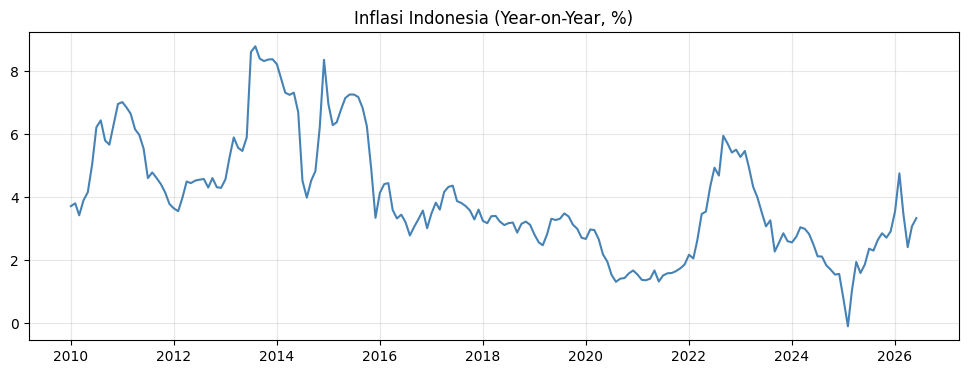

Train: (148, 12), Test: (38, 12)


In [58]:
# ===== 1. PREPROCESSING =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
N_LAGS = 12

df = pd.read_csv('inflasi.csv')
df['periode'] = pd.to_datetime(df['periode'])
df = df.sort_values('periode').reset_index(drop=True)

# EDA singkat
plt.figure(figsize=(12, 4))
plt.plot(df['periode'], df['inflasi'], color='steelblue')
plt.title('Inflasi Indonesia (Year-on-Year, %)')
plt.grid(alpha=0.3); plt.show()

values = df['inflasi'].values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values).flatten()

X, y = [], []
for i in range(N_LAGS, len(scaled)):
    X.append(scaled[i-N_LAGS:i]); y.append(scaled[i])
X, y = np.array(X), np.array(y)

split = int(len(X) * 0.8)  # split kronologis, tanpa shuffle
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

In [59]:
# ===== 2. BASELINE SVR (SEBELUM OPTIMASI) =====
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluasi(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.2f}%')
    return rmse, mae, mape

svr_base = SVR(kernel='rbf')  # default: C=1.0, gamma='scale', epsilon=0.1
svr_base.fit(X_train, y_train)
pred_base = svr_base.predict(X_test)

y_test_asli = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
pred_base_asli = scaler.inverse_transform(pred_base.reshape(-1, 1)).flatten()
hasil_base = evaluasi(y_test_asli, pred_base_asli, 'SVR Baseline')

SVR Baseline -> RMSE: 0.6897 | MAE: 0.5247 | MAPE: 87.01%


2026-07-21 05:45:50,161 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}


Memulai optimasi PSO pada dataset multi-fitur...


pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.107
2026-07-21 05:45:56,711 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.10687182907566457, best pos: [2.01783724e+02 2.29455069e-01 1.44763245e-01]



Parameter Optimal Baru: C=201.7837, gamma=0.2295, epsilon=0.1448


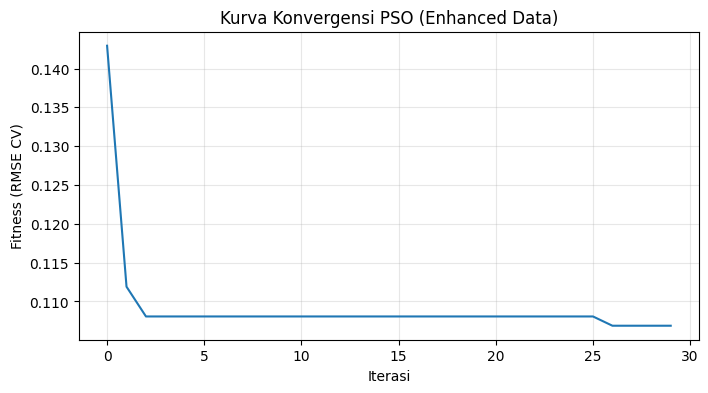

In [60]:
# ===== 3. RE-OPTIMASI PSO (DENGAN ENHANCED DATA) =====
!pip install pyswarms -q
import pyswarms as ps
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Batas pencarian parameter [C, gamma, epsilon]
LB = np.array([0.1, 0.0001, 0.0001])
UB = np.array([1000., 10., 0.5])

def fitness_enhanced(particles):
    scores = []
    tscv = TimeSeriesSplit(n_splits=3)
    for p in particles:
        C, gamma, eps = p
        rmses = []
        for tr, va in tscv.split(X_train):
            m = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=eps)
            m.fit(X_train[tr], y_train[tr])
            rmses.append(np.sqrt(mean_squared_error(y_train[va], m.predict(X_train[va]))))
        scores.append(np.mean(rmses))
    return np.array(scores)

options = {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
optimizer = ps.single.GlobalBestPSO(n_particles=20, dimensions=3,
                                    options=options, bounds=(LB, UB))

print("Memulai optimasi PSO pada dataset multi-fitur...")
best_cost, best_pos = optimizer.optimize(fitness_enhanced, iters=30)

C_opt, gamma_opt, eps_opt = best_pos
print(f'\nParameter Optimal Baru: C={C_opt:.4f}, gamma={gamma_opt:.4f}, epsilon={eps_opt:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(optimizer.cost_history)
plt.title('Kurva Konvergensi PSO (Enhanced Data)')
plt.xlabel('Iterasi'); plt.ylabel('Fitness (RMSE CV)')
plt.grid(alpha=0.3); plt.show()


=== PERBANDINGAN METRIK PERFORMA (AKURASI) ===


,Model,RMSE,MAE,MAPE (%),Akurasi (%)
0,SVR Baseline,0.6897,0.5247,87.0107,12.9893
1,SVR-PSO (Optimized),0.7009,0.5539,43.3562,56.6438



=== SAMPEL HASIL PREDIKSI (10 DATA TERAKHIR) ===


,Periode,Aktual,Prediksi Baseline,Prediksi SVR-PSO
28,2025-09,2.65,2.8410,2.2407
29,2025-10,2.86,3.0054,2.4526
30,2025-11,2.72,3.2118,2.4868
31,2025-12,2.92,3.3467,2.3680
32,2026-01,3.55,3.5321,2.4733
33,2026-02,4.76,3.7504,2.9680
34,2026-03,3.48,4.1617,4.2744
35,2026-04,2.42,4.0883,3.4683
36,2026-05,3.08,3.8156,2.8105
37,2026-06,3.34,3.7203,3.6753


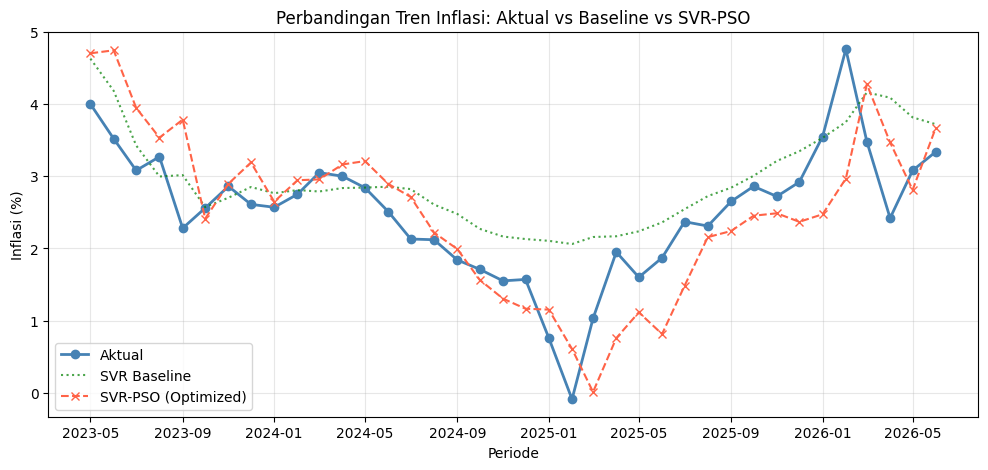

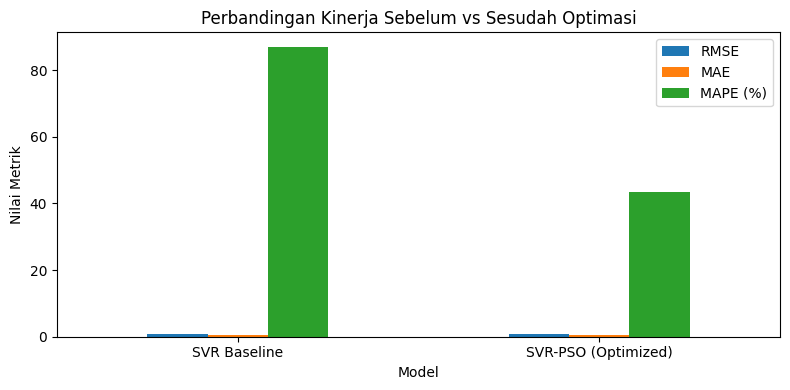

In [61]:
# ===== 4. EVALUASI & TABEL PERBANDINGAN FINAL =====
def evaluasi_final(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # Menghitung MAPE dengan penanganan pembagian nol
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    akurasi = 100 - mape
    return [label, rmse, mae, mape, akurasi]

# 1. Hitung ulang hasil dengan parameter optimal
svr_base.fit(X_train, y_train)
pred_base_asli = scaler.inverse_transform(svr_base.predict(X_test).reshape(-1, 1)).flatten()

svr_pso_final = SVR(kernel='rbf', C=C_opt, gamma=gamma_opt, epsilon=eps_opt)
svr_pso_final.fit(X_train, y_train)
pred_pso_asli = scaler.inverse_transform(svr_pso_final.predict(X_test).reshape(-1, 1)).flatten()
y_test_asli = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 2. Tabel Metrik (Akurasi)
metrics_data = [
    evaluasi_final(y_test_asli, pred_base_asli, 'SVR Baseline'),
    evaluasi_final(y_test_asli, pred_pso_asli, 'SVR-PSO (Optimized)')
]
tabel_metrik = pd.DataFrame(metrics_data, columns=['Model', 'RMSE', 'MAE', 'MAPE (%)', 'Akurasi (%)'])

print("\n=== PERBANDINGAN METRIK PERFORMA (AKURASI) ===")
display(tabel_metrik.round(4))

# 3. Ambil tanggal yang selaras dengan dimensi X_test
tanggal_test = df['periode'].iloc[-len(y_test_asli):].reset_index(drop=True)

# 4. Tabel Prediksi
tabel_prediksi = pd.DataFrame({
    'Periode': tanggal_test.dt.strftime('%Y-%m'),
    'Aktual': y_test_asli,
    'Prediksi Baseline': pred_base_asli,
    'Prediksi SVR-PSO': pred_pso_asli
})

print("\n=== SAMPEL HASIL PREDIKSI (10 DATA TERAKHIR) ===")
display(tabel_prediksi.tail(10).round(4))

# 5. Visualisasi Tren (Ditambahkan Prediksi Baseline)
plt.figure(figsize=(12, 5))
plt.plot(tanggal_test, y_test_asli, label='Aktual', color='steelblue', marker='o', linewidth=2)
plt.plot(tanggal_test, pred_base_asli, label='SVR Baseline', color='green', ls=':', alpha=0.7)
plt.plot(tanggal_test, pred_pso_asli, label='SVR-PSO (Optimized)', color='tomato', ls='--', marker='x')
plt.title('Perbandingan Tren Inflasi: Aktual vs Baseline vs SVR-PSO')
plt.xlabel('Periode')
plt.ylabel('Inflasi (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Grafik batang perbandingan metrik
tabel_metrik.set_index('Model')[['RMSE', 'MAE', 'MAPE (%)']].plot(kind='bar', figsize=(8, 4), rot=0)
plt.title('Perbandingan Kinerja Sebelum vs Sesudah Optimasi')
plt.ylabel('Nilai Metrik')
plt.tight_layout()
plt.show()